In [1]:
# Mount Google Drive (safe to rerun) and point to the project folder
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/Group4_project'
EMNIST_DIR = f'{PROJECT}/emnist'
!ls -lh {PROJECT}

Mounted at /content/drive
total 1.7M
-rw------- 1 root root 1.7M Oct  3 21:04 char_cnn_best.pt
drwx------ 2 root root 4.0K Oct  3 19:36 emnist
-rw------- 1 root root 5.7K Oct  3 21:03 form_layout.json
drwx------ 2 root root 4.0K Oct  3 19:43 synthetic_logs


In [2]:
import gzip
import numpy as np

def load_idx_images(path):
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rb') as f:
        data = f.read()
    magic, n, rows, cols = np.frombuffer(data[:16], dtype='>i4')
    assert magic == 2051, f"Not an idx image file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=16).reshape(n, rows, cols)

def load_idx_labels(path):
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rb') as f:
        data = f.read()
    magic, n = np.frombuffer(data[:8], dtype='>i4')
    assert magic == 2049, f"Not an idx label file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=8)

def load_emnist(split):
    x = load_idx_images(f'{EMNIST_DIR}/emnist-byclass-{split}-images-idx3-ubyte.gz')
    y = load_idx_labels(f'{EMNIST_DIR}/emnist-byclass-{split}-labels-idx1-ubyte.gz')
    x = np.ascontiguousarray(x.transpose(0, 2, 1))  # EMNIST is stored transposed
    return x, y

EMNIST_MAP = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
x_train_all, y_train_all = load_emnist('train')
x_test_all,  y_test_all  = load_emnist('test')
print(x_train_all.shape, x_test_all.shape)

(697932, 28, 28) (116323, 28, 28)


Orientation OK: average '1' is 22 tall x 12 wide


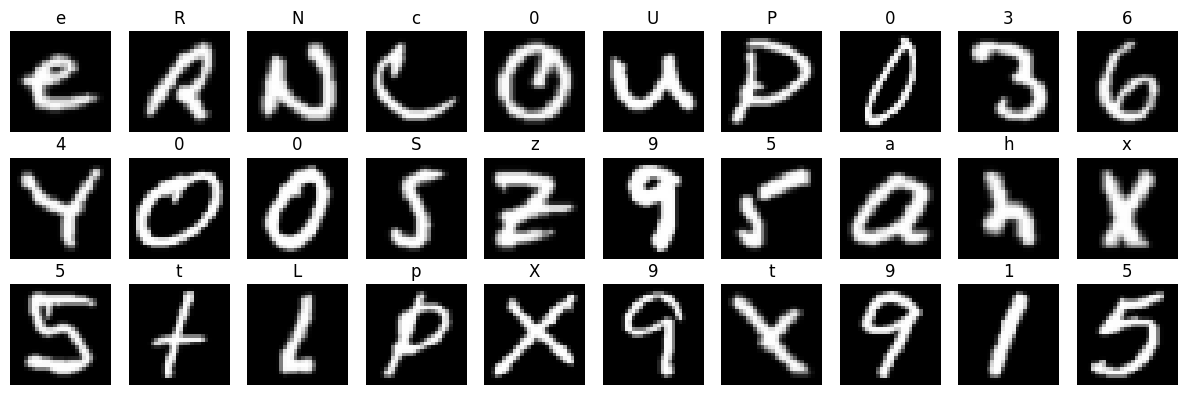

In [3]:
import matplotlib.pyplot as plt

def ink_extent(img, thr=60):
    rows = np.where(img.max(axis=1) > thr)[0]
    cols = np.where(img.max(axis=0) > thr)[0]
    return np.ptp(rows) + 1, np.ptp(cols) + 1   # height, width

mean_one = x_train_all[y_train_all == 1][:2000].mean(axis=0)
h, w = ink_extent(mean_one)
assert h > w, f"Average '1' is {h}x{w} (h x w) -- images look sideways, check the transpose"
print(f"Orientation OK: average '1' is {h} tall x {w} wide")

fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for ax, i in zip(axes.flat, np.random.default_rng(0).choice(len(x_train_all), 30, replace=False)):
    ax.imshow(x_train_all[i], cmap='gray')
    ax.set_title(EMNIST_MAP[y_train_all[i]])
    ax.axis('off')
plt.tight_layout(); plt.show()

In [4]:
keep_tr = y_train_all < 36   # 0-9 = digits, 10-35 = A-Z; drop lowercase
keep_te = y_test_all < 36
x_train_full, y_train_full = x_train_all[keep_tr], y_train_all[keep_tr]
x_test,  y_test            = x_test_all[keep_te],  y_test_all[keep_te]

rng = np.random.default_rng(42)
perm = rng.permutation(len(x_train_full))
n_val = int(0.1 * len(perm))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
x_train, y_train = x_train_full[tr_idx], y_train_full[tr_idx]
x_val,   y_val   = x_train_full[val_idx], y_train_full[val_idx]

for name, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f"{name}: {len(y):,} total | digits {np.sum(y < 10):,} | letters {np.sum(y >= 10):,}")

train: 480,594 total | digits 310,350 | letters 170,244
val: 53,399 total | digits 34,685 | letters 18,714
test: 89,264 total | digits 57,918 | letters 31,346


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def to_model_input(x_uint8):
    """(N,28,28) uint8, white ink on black -> (N,1,28,28) float in [-1, 1].
    Use this SAME function at inference on every cell crop."""
    x = torch.from_numpy(np.asarray(x_uint8)).float().div(255.0)
    return ((x - 0.5) / 0.5).unsqueeze(1)

train_ds = TensorDataset(to_model_input(x_train), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(to_model_input(x_val),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(to_model_input(x_test),  torch.from_numpy(y_test).long())

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

In [6]:
import cv2, json, os
import datetime as dt
from PIL import Image, ImageDraw, ImageFont

FORM_W, FORM_H, BOX = 2200, 1400, 62

# Glyph bank: TEST split only (digits + capitals), so no training image ever appears in a test log
glyph_bank = {EMNIST_MAP[c]: x_test[y_test == c] for c in range(36)}

def get_font(size, bold=False):
    name = 'LiberationSans-Bold.ttf' if bold else 'LiberationSans-Regular.ttf'
    try:
        return ImageFont.truetype(f'/usr/share/fonts/truetype/liberation/{name}', size)
    except OSError:
        return ImageFont.load_default()

def draw_boxes(draw, fields, name, x, y, n, sep_after=()):
    rects = []
    for i in range(n):
        rects.append((x, y, x + BOX, y + BOX))
        draw.rectangle(rects[-1], outline=(70, 90, 120), width=2)
        x += BOX
        if i in sep_after:
            draw.text((x + 6, y + 8), '/', font=get_font(40), fill=(70, 90, 120))
            x += 30
    fields[name] = rects

def build_form(n_rows=9):
    img = Image.new('RGB', (FORM_W, FORM_H), (250, 249, 244))
    d = ImageDraw.Draw(img)
    fields = {}
    d.text((80, 50), 'SABAL COAST HOME HEALTH', font=get_font(48, True), fill=(20, 45, 90))
    d.text((80, 112), 'Weekly Field Mileage Log - Form ML-7', font=get_font(32), fill=(40, 40, 40))
    d.text((80, 206), 'EMPLOYEE ID', font=get_font(28, True), fill=(30, 30, 30))
    draw_boxes(d, fields, 'emp_id', 290, 190, 6)
    d.text((820, 206), 'WEEK ENDING (MM/DD/YY)', font=get_font(28, True), fill=(30, 30, 30))
    draw_boxes(d, fields, 'week_ending', 1190, 190, 6, sep_after=(1, 3))
    d.rectangle((70, 350, 2130, 400), fill=(225, 231, 240))
    for label, x in [('#', 80), ('DATE (MM/DD)', 170), ('CLIENT', 520), ('ODOMETER START', 760),
                     ('ODOMETER END', 1200), ('MILES', 1640)]:
        d.text((x, 362), label, font=get_font(24, True), fill=(20, 45, 90))
    y = 420
    for r in range(n_rows):
        d.text((90, y + 14), str(r + 1), font=get_font(28), fill=(90, 90, 90))
        draw_boxes(d, fields, f'r{r}_date', 170, y, 4, sep_after=(1,))
        draw_boxes(d, fields, f'r{r}_client', 520, y, 3)
        draw_boxes(d, fields, f'r{r}_odo_start', 760, y, 6)
        draw_boxes(d, fields, f'r{r}_odo_end', 1200, y, 6)
        draw_boxes(d, fields, f'r{r}_miles', 1640, y, 3)
        y += BOX + 24
    d.text((1300, y + 18), 'TOTAL MILES', font=get_font(28, True), fill=(30, 30, 30))
    draw_boxes(d, fields, 'total_miles', 1640 - BOX, y, 4)
    return img, fields

In [7]:
def write_field(ink, rects, text, rng, messy=0.0):
    """Place one EMNIST glyph per box. messy (0-1) increases size, tilt and position jitter."""
    for (x0, y0, x1, y1), ch in zip(rects, text):
        bank = glyph_bank[ch]
        g = bank[rng.integers(len(bank))].astype(np.float32) / 255.0
        size = int(BOX * rng.uniform(0.85, 1.0 + 0.25 * messy))
        g = cv2.resize(g, (size, size), interpolation=cv2.INTER_CUBIC)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), rng.normal(0, 4 + 6 * messy), 1.0)
        g = np.clip(cv2.warpAffine(g, M, (size, size)), 0, 1)
        cx = (x0 + x1) / 2 + rng.normal(0, 2 + 7 * messy)
        cy = (y0 + y1) / 2 + rng.normal(0, 2 + 7 * messy)
        px, py = int(cx - size / 2), int(cy - size / 2)
        ys, xs = max(py, 0), max(px, 0)
        ye, xe = min(py + size, ink.shape[0]), min(px + size, ink.shape[1])
        ink[ys:ye, xs:xe] = np.maximum(ink[ys:ye, xs:xe], g[ys - py:ye - py, xs - px:xe - px])

def compose(form_img, ink, ink_rgb=(25, 35, 90)):
    """Blend the ink layer onto the paper (EMNIST white-on-black becomes dark ink on light paper)."""
    paper = np.asarray(form_img, np.float32)
    a = np.clip(ink * 1.15, 0, 1)[..., None]
    return (paper * (1 - a) + np.array(ink_rgb, np.float32) * a).astype(np.uint8)

def degrade(img, rng, strength=1.0):
    """Make a clean page look like a phone photo: uneven light, blur, noise, skew, JPEG."""
    if strength <= 0:
        return img
    a = img.astype(np.float32)
    H, W = a.shape[:2]
    yy, xx = np.mgrid[0:H, 0:W]
    light = 1.0 - 0.20 * strength * (xx / W) - 0.10 * strength * (yy / H)
    a = a * light[..., None]
    a = cv2.GaussianBlur(a, (0, 0), 0.5 + 1.0 * strength)
    a = a + rng.normal(0, 6 * strength, a.shape)
    a = np.clip(a, 0, 255).astype(np.uint8)
    j = 0.015 * strength
    src = np.float32([[0, 0], [W, 0], [W, H], [0, H]])
    dst = (src + rng.uniform(-j, j, (4, 2)) * np.array([W, H])).astype(np.float32)
    a = cv2.warpPerspective(a, cv2.getPerspectiveTransform(src, dst), (W, H), borderValue=(60, 60, 60))
    _, enc = cv2.imencode('.jpg', a[..., ::-1], [cv2.IMWRITE_JPEG_QUALITY, int(90 - 45 * strength)])
    return cv2.imdecode(enc, 1)[..., ::-1]

In [8]:
LETTERS = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

def random_log_data(rng, n_rows=None):
    """Valid log: Sunday week-ending, dates inside the week, odometers running forward, miles = end - start."""
    n_rows = n_rows or int(rng.integers(4, 10))
    emp = ''.join(rng.choice(LETTERS, 2)) + f'{rng.integers(0, 10000):04d}'
    week_end = dt.date(2026, 9, 6) + dt.timedelta(weeks=int(rng.integers(0, 8)))  # Sept 6, 2026 is a Sunday
    clients = [''.join(rng.choice(LETTERS, 3)) for _ in range(4)]
    odo = int(rng.integers(1000, 900000))
    rows = []
    for d in sorted(rng.integers(0, 7, n_rows)):
        date = week_end - dt.timedelta(days=int(6 - d))
        odo += int(rng.integers(0, 15))          # personal miles between trips
        miles = int(rng.integers(5, 100))
        rows.append({'date': date.strftime('%m%d'), 'client': str(rng.choice(clients)),
                     'odo_start': f'{odo:06d}', 'odo_end': f'{odo + miles:06d}', 'miles': f'{miles:03d}'})
        odo += miles
    total = sum(int(r['miles']) for r in rows)
    return {'emp_id': emp, 'week_ending': week_end.strftime('%m%d%y'),
            'rows': rows, 'total_miles': f'{total:04d}'}

def make_log(data, rng, messy=0.1, strength=0.0):
    form_img, fields = build_form()
    ink = np.zeros((FORM_H, FORM_W), np.float32)
    write_field(ink, fields['emp_id'], data['emp_id'], rng, messy)
    write_field(ink, fields['week_ending'], data['week_ending'], rng, messy)
    for r, row in enumerate(data['rows']):
        for key in ['date', 'client', 'odo_start', 'odo_end', 'miles']:
            write_field(ink, fields[f'r{r}_{key}'], row[key], rng, messy)
    write_field(ink, fields['total_miles'], data['total_miles'], rng, messy)
    return degrade(compose(form_img, ink), rng, strength), fields

60 logs saved to synthetic_logs/


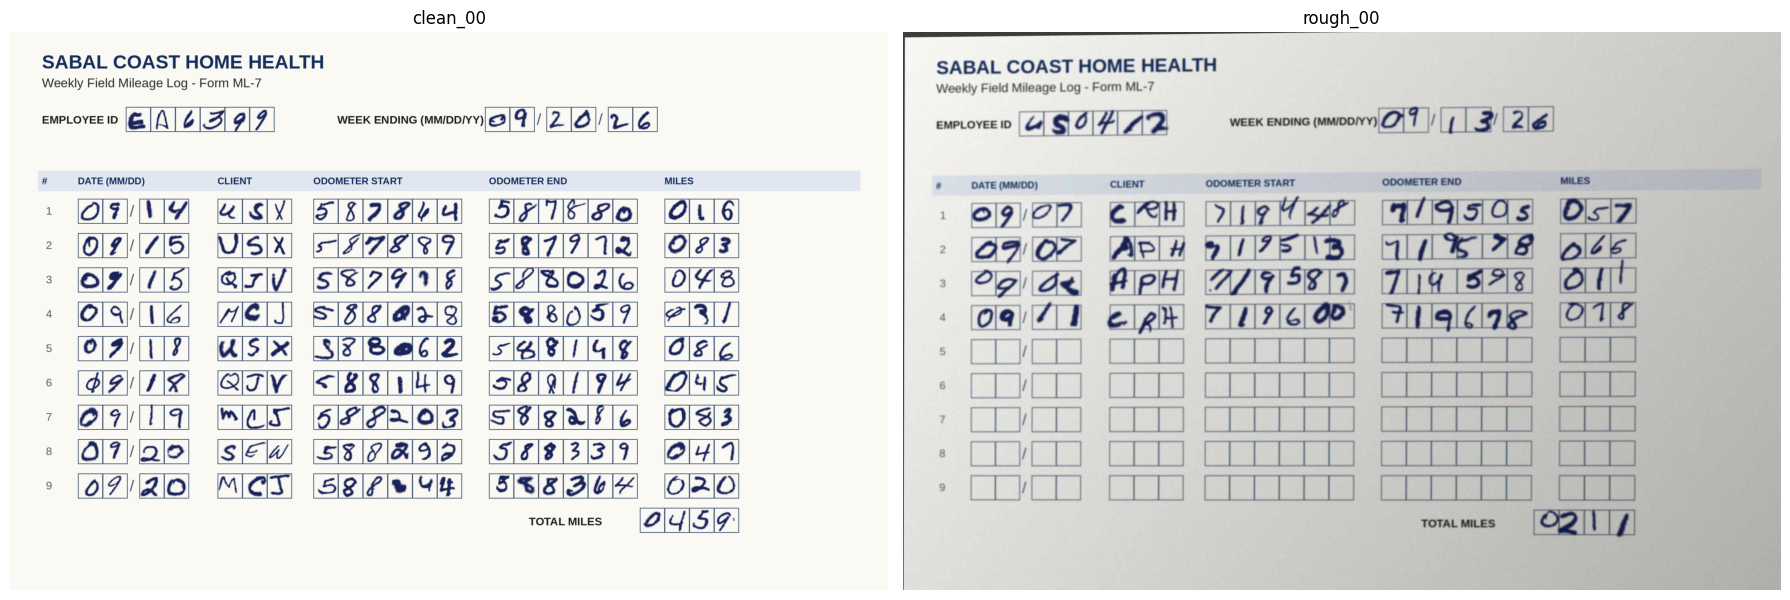

{'date': '0914', 'client': 'USX', 'odo_start': '587864', 'odo_end': '587880', 'miles': '016'}


In [9]:
out_dir = 'synthetic_logs'
os.makedirs(out_dir, exist_ok=True)
rng = np.random.default_rng(2026)

# condition name: (messy handwriting, photo degradation strength)
conditions = {'clean': (0.1, 0.0), 'phone': (0.5, 0.6), 'rough': (0.75, 1.0)}
n_per_condition = 20

for cond, (messy, strength) in conditions.items():
    for i in range(n_per_condition):
        data = random_log_data(rng)
        img, fields = make_log(data, rng, messy, strength)
        name = f'{cond}_{i:02d}'
        cv2.imwrite(f'{out_dir}/{name}.png', img[..., ::-1])
        json.dump({**data, 'condition': cond, 'messy': messy, 'degrade_strength': strength},
                  open(f'{out_dir}/{name}.json', 'w'), indent=1)

json.dump(fields, open('form_layout.json', 'w'))   # box coordinates of the blank form
print(f"{len(os.listdir(out_dir)) // 2} logs saved to {out_dir}/")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, name in zip(axes, ['clean_00', 'rough_00']):
    ax.imshow(cv2.imread(f'{out_dir}/{name}.png')[..., ::-1])
    ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()
print(json.load(open(f'{out_dir}/clean_00.json'))['rows'][0])

In [10]:
import shutil
from google.colab import files

shutil.make_archive('synthetic_logs', 'zip', '.', 'synthetic_logs')
files.download('synthetic_logs.zip')
files.download('form_layout.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using', device)

class CharCNN(nn.Module):
    def __init__(self, n_classes=36):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1x28x28  -> 32x28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32x14x14 -> 64x14x14
        self.pool = nn.MaxPool2d(2)                               # halves height and width
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))      # -> 32x14x14
        x = self.pool(F.relu(self.conv2(x)))      # -> 64x7x7
        x = x.view(x.size(0), -1)                 # flatten
        x = self.dropout(F.relu(self.fc1(x)))
        return F.log_softmax(self.fc2(x), dim=1)  # same output style as your MNIST model

model = CharCNN().to(device)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Using cuda
CharCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=36, bias=True)
)
Trainable parameters: 424996


In [12]:
# Class weights: rare classes (letters like Q, X, Z) count more in the loss,
# because client codes on the form use letters close to uniformly
counts = np.bincount(y_train, minlength=36)
class_weights = torch.tensor(counts.sum() / (36 * counts), dtype=torch.float32).to(device)

criterion = nn.NLLLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

EPOCHS = 5
SAVE_PATH = '/content/drive/MyDrive/Group4_project/char_cnn_best.pt'
history, best_val = [], 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * y.size(0)
    train_loss = running_loss / len(train_ds)
    val_acc = evaluate(model, val_loader)
    history.append((epoch + 1, train_loss, val_acc))
    print(f'Epoch {epoch + 1}/{EPOCHS} | train loss {train_loss:.4f} | val acc {val_acc:.2%}')
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), SAVE_PATH)   # keep the best epoch, saved to Drive

print(f'Best validation accuracy: {best_val:.2%} (saved to {SAVE_PATH})')

Epoch 1/5 | train loss 0.4816 | val acc 89.68%
Epoch 2/5 | train loss 0.2762 | val acc 90.90%
Epoch 3/5 | train loss 0.2374 | val acc 90.57%
Epoch 4/5 | train loss 0.2134 | val acc 90.84%
Epoch 5/5 | train loss 0.1987 | val acc 91.33%
Best validation accuracy: 91.33% (saved to /content/drive/MyDrive/Group4_project/char_cnn_best.pt)


In [13]:
DIGITS = list(range(10))
LETTERS_IDX = list(range(10, 36))

def predict(model, x, allowed=None):
    """Returns (predicted class, confidence). allowed = class indices the field permits."""
    logp = model(x)
    if allowed is not None:
        mask = torch.full_like(logp, float('-inf'))
        mask[:, allowed] = 0
        logp = logp + mask
    probs = torch.softmax(logp, dim=1)    # renormalized over the allowed classes
    conf, pred = probs.max(dim=1)
    return pred, conf

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

free, as_digit, as_letter = [], [], []
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        free.append(predict(model, x)[0].cpu())
        as_digit.append(predict(model, x, DIGITS)[0].cpu())
        as_letter.append(predict(model, x, LETTERS_IDX)[0].cpu())
free, as_digit, as_letter = (torch.cat(p).numpy() for p in (free, as_digit, as_letter))

is_digit = y_test < 10
print('Condition: isolated EMNIST test-split characters (clean, centered, no form)\n')
print(f"Digits,  free choice (36 classes):  {(free[is_digit] == y_test[is_digit]).mean():.2%}")
print(f"Digits,  restricted to 0-9:         {(as_digit[is_digit] == y_test[is_digit]).mean():.2%}")
print(f"Letters, free choice (36 classes):  {(free[~is_digit] == y_test[~is_digit]).mean():.2%}")
print(f"Letters, restricted to A-Z:         {(as_letter[~is_digit] == y_test[~is_digit]).mean():.2%}")
print(f"Overall, free choice:               {(free == y_test).mean():.2%}")

Condition: isolated EMNIST test-split characters (clean, centered, no form)

Digits,  free choice (36 classes):  91.82%
Digits,  restricted to 0-9:         99.34%
Letters, free choice (36 classes):  90.47%
Letters, restricted to A-Z:         97.86%
Overall, free choice:               91.34%


In [14]:
from scipy import ndimage

PROJECT = '/content/drive/MyDrive/Group4_project'

# Template = your own blank Form ML-7, drawn by build_form() from the generator cells
template_img, _ = build_form()
template_gray = cv2.cvtColor(np.asarray(template_img), cv2.COLOR_RGB2GRAY)
fields = json.load(open(f'{PROJECT}/form_layout.json'))

sift = cv2.SIFT_create(nfeatures=5000)
tmpl_kp, tmpl_des = sift.detectAndCompute(template_gray, None)

def register_form(photo_bgr, min_inliers=40):
    """Straighten a photo of Form ML-7 onto the blank template (handles skew, rotation, scale)."""
    gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY)
    scale = 1.0
    if max(gray.shape) > 3000:                      # phone photos can be huge; shrink for speed
        scale = 3000 / max(gray.shape)
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    kp, des = sift.detectAndCompute(gray, None)
    if des is None:
        raise ValueError('No features found in photo')
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    good = [m for m, n in matcher.knnMatch(des, tmpl_des, k=2) if m.distance < 0.75 * n.distance]
    if len(good) < min_inliers:
        raise ValueError(f'Only {len(good)} feature matches -- is the whole form in the photo?')
    src = np.float32([kp[m.queryIdx].pt for m in good]) / scale
    dst = np.float32([tmpl_kp[m.trainIdx].pt for m in good])
    H, inlier_mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or int(inlier_mask.sum()) < min_inliers:
        raise ValueError('Registration failed -- photo too blurry, cropped, or not Form ML-7')
    h, w = template_gray.shape
    warped = cv2.warpPerspective(photo_bgr, H, (w, h), borderValue=(255, 255, 255))
    return warped, int(inlier_mask.sum())

print('Template ready:', template_gray.shape, '|', len(tmpl_kp), 'features')

Template ready: (1400, 2200) | 2025 features


In [15]:
def ink_map(warped_bgr):
    """Dark ink on light paper -> ink strength 0-1 (white on black), evening out shadows and uneven light."""
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    background = cv2.medianBlur(gray.astype(np.uint8), 51).astype(np.float32)
    ink = np.clip(background - gray, 0, None)
    ink = np.clip(ink / max(np.percentile(ink, 99.9), 1.0), 0, 1)
    ink[ink < 0.15] = 0
    return ink

def erase_box_lines(ink, line_px=4):
    """We know exactly where the printed box lines are after registration, so blank them out."""
    out = ink.copy()
    for rects in fields.values():
        for x0, y0, x1, y1 in rects:
            out[y0 - line_px:y0 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y1 - line_px:y1 + line_px, x0 - line_px:x1 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x0 - line_px:x0 + line_px] = 0
            out[y0 - line_px:y1 + line_px, x1 - line_px:x1 + line_px] = 0
    return out

def to_emnist28(cell):
    """Same normalization as EMNIST: crop to ink, fit in 20x20, center by mass in 28x28, uint8 0-255."""
    ys, xs = np.nonzero(cell > 0.15)
    if len(ys) == 0:
        return np.zeros((28, 28), np.uint8)
    cell = cell[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = cell.shape
    s = 20.0 / max(h, w)
    cell = cv2.resize(cell, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    out = np.zeros((28, 28), np.float32)
    h, w = cell.shape
    y0, x0 = (28 - h) // 2, (28 - w) // 2
    out[y0:y0 + h, x0:x0 + w] = cell
    cy, cx = ndimage.center_of_mass(out)
    out = ndimage.shift(out, (14 - cy, 14 - cx), order=1)
    out = out / max(out.max(), 1e-6)
    return (np.clip(out, 0, 1) * 255).astype(np.uint8)

def extract_cells(photo_bgr, pad=6, min_ink=0.015):
    """Photo in -> {field name: [28x28 crop or None for an empty box]}."""
    warped, n_inliers = register_form(photo_bgr)
    ink = erase_box_lines(ink_map(warped))
    cells = {}
    for name, rects in fields.items():
        crops = []
        for x0, y0, x1, y1 in rects:
            region = ink[y0 - pad:y1 + pad, x0 - pad:x1 + pad]
            if (region > 0.3).mean() < min_ink:          # almost no ink -> empty box
                crops.append(None)
                continue
            # keep only ink strokes that reach the middle of the box (ignores spillover from neighbors)
            lab, _ = ndimage.label(region > 0.15)
            H_, W_ = region.shape
            ids = [i for i in np.unique(lab[H_ // 4:3 * H_ // 4, W_ // 4:3 * W_ // 4]) if i > 0]
            if not ids:
                crops.append(None)
                continue
            crops.append(to_emnist28(region * np.isin(lab, ids)))
        cells[name] = crops
    return cells, warped, n_inliers

Registration inliers: 161 | filled cells found: 104 (expected 104)


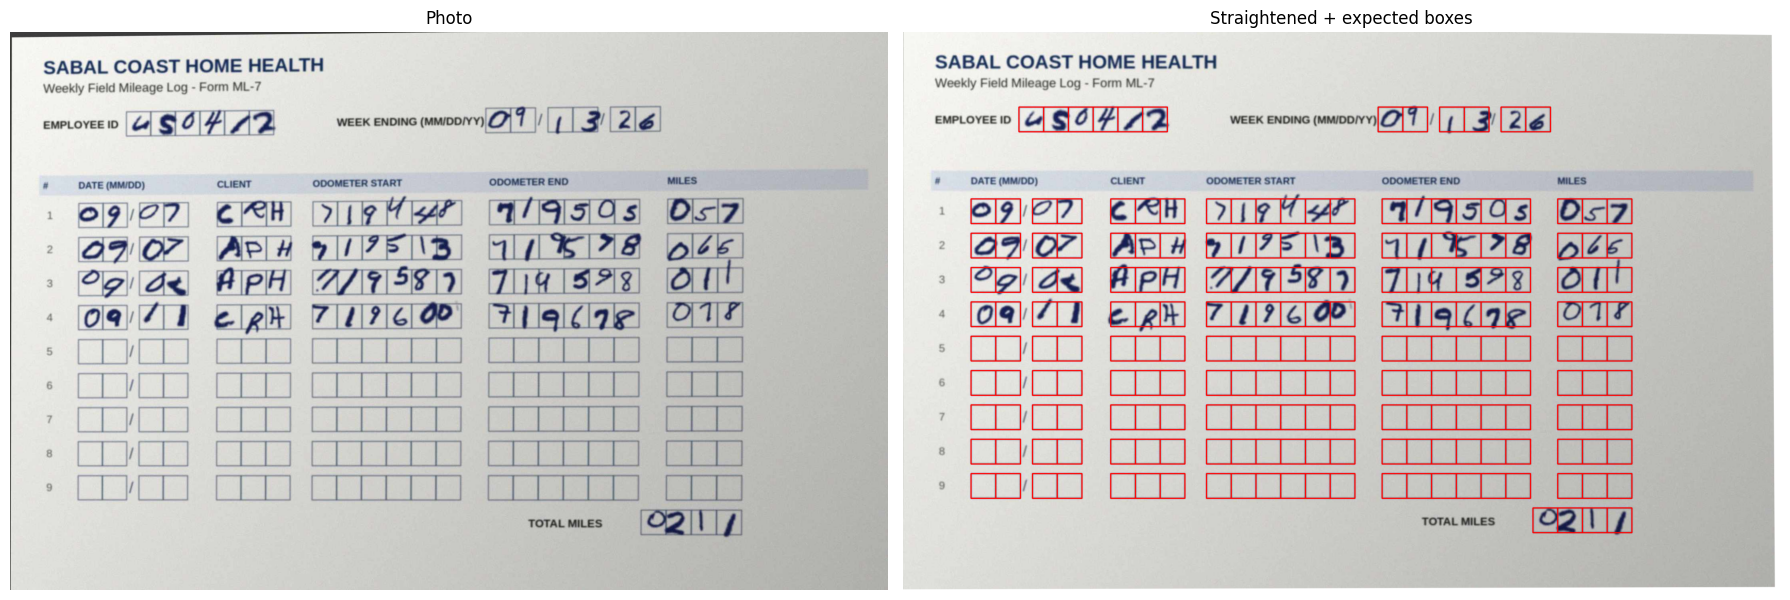

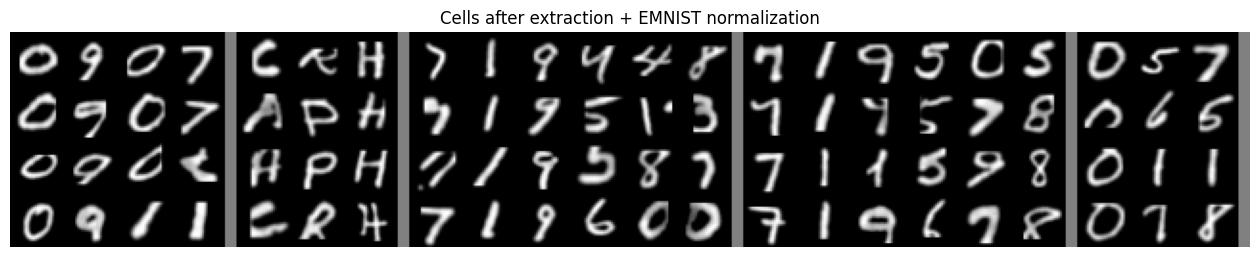

In [16]:
photo = cv2.imread(f'{PROJECT}/synthetic_logs/rough_00.png')
cells, warped, n_inliers = extract_cells(photo)
n_filled = sum(c is not None for crops in cells.values() for c in crops)
truth = json.load(open(f'{PROJECT}/synthetic_logs/rough_00.json'))
expected = 12 + 22 * len(truth['rows']) + 4
print(f'Registration inliers: {n_inliers} | filled cells found: {n_filled} (expected {expected})')

overlay = warped.copy()
for rects in fields.values():
    for x0, y0, x1, y1 in rects:
        cv2.rectangle(overlay, (x0, y0), (x1, y1), (0, 0, 255), 2)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(photo[..., ::-1]); axes[0].set_title('Photo')
axes[1].imshow(overlay[..., ::-1]); axes[1].set_title('Straightened + expected boxes')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

blank = np.full((28, 28), 80, np.uint8)
sep = np.full((28, 6), 128, np.uint8)
rows = []
for r in range(len(truth['rows'])):
    parts = []
    for key in ['date', 'client', 'odo_start', 'odo_end', 'miles']:
        parts += [c if c is not None else blank for c in cells[f'r{r}_{key}']] + [sep]
    rows.append(np.hstack(parts))
plt.figure(figsize=(16, 0.8 * len(rows)))
plt.imshow(np.vstack(rows), cmap='gray'); plt.axis('off')
plt.title('Cells after extraction + EMNIST normalization'); plt.show()

In [17]:
import re

def allowed_classes(field, i):
    """Which classes a box may contain, from the form rules."""
    base = field.split('_', 1)[1] if re.match(r'r\d_', field) else field
    if base == 'client':
        return LETTERS_IDX
    if base == 'emp_id':
        return LETTERS_IDX if i < 2 else DIGITS   # 2 letters + 4 digits
    return DIGITS                                  # dates, odometers, miles, total

def read_cells(cells):
    """{field: [crops]} -> {field: (text read, [confidence per box])}. Empty box = ' '."""
    out = {}
    model.eval()
    for field, crops in cells.items():
        chars, confs = [], []
        for i, crop in enumerate(crops):
            if crop is None:
                chars.append(' '); confs.append(None)
                continue
            x = to_model_input(crop[None]).to(device)
            with torch.no_grad():
                pred, conf = predict(model, x, allowed_classes(field, i))
            chars.append(EMNIST_MAP[pred.item()]); confs.append(conf.item())
        out[field] = (''.join(chars), confs)
    return out

def truth_fields(truth):
    t = {'emp_id': truth['emp_id'], 'week_ending': truth['week_ending'], 'total_miles': truth['total_miles']}
    for r, row in enumerate(truth['rows']):
        for key in ['date', 'client', 'odo_start', 'odo_end', 'miles']:
            t[f'r{r}_{key}'] = row[key]
    return t

reads = read_cells(cells)
gt = truth_fields(truth)

n_char = n_char_ok = n_field_ok = 0
print(f"{'field':<14}{'truth':<9}{'read':<9}{'ok':<4}lowest conf")
for field, true_text in gt.items():
    read_text, confs = reads[field]
    ok = read_text == true_text
    n_field_ok += ok
    n_char += len(true_text)
    n_char_ok += sum(a == b for a, b in zip(read_text, true_text))
    low = min(c for c in confs if c is not None) if any(c is not None for c in confs) else 0
    print(f"{field:<14}{true_text:<9}{read_text:<9}{'✓' if ok else '✗':<4}{low:.2f}")

print(f"\nCondition: {truth['condition']} (synthetic log rough_00)")
print(f"Character accuracy: {n_char_ok}/{n_char} = {n_char_ok / n_char:.1%}")
print(f"Field accuracy:     {n_field_ok}/{len(gt)} = {n_field_ok / len(gt):.1%}")

field         truth    read     ok  lowest conf
emp_id        US0412   US0412   ✓   0.75
week_ending   091326   091326   ✓   0.77
total_miles   0211     0211     ✓   0.99
r0_date       0907     0907     ✓   1.00
r0_client     CRH      CRH      ✓   0.69
r0_odo_start  719448   719448   ✓   0.66
r0_odo_end    719505   719505   ✓   0.89
r0_miles      057      057      ✓   0.99
r1_date       0907     0907     ✓   0.57
r1_client     APH      APH      ✓   0.85
r1_odo_start  719513   719513   ✓   0.89
r1_odo_end    719578   717578   ✗   0.56
r1_miles      065      066      ✗   0.70
r2_date       0908     0002     ✗   0.50
r2_client     APH      HPH      ✗   0.95
r2_odo_start  719587   719287   ✗   0.50
r2_odo_end    719598   711598   ✗   0.96
r2_miles      011      011      ✓   1.00
r3_date       0911     0911     ✓   0.75
r3_client     CRH      CRH      ✓   0.80
r3_odo_start  719600   719600   ✓   0.79
r3_odo_end    719678   710678   ✗   0.41
r3_miles      078      078      ✓   0.80

Conditio

In [18]:
import glob
import pandas as pd

char_rows, field_rows, reg_failures = [], [], []

for path in sorted(glob.glob(f'{PROJECT}/synthetic_logs/*.png')):
    name = os.path.basename(path)[:-4]
    truth_i = json.load(open(path[:-4] + '.json'))
    cond = truth_i['condition']
    try:
        cells_i, _, _ = extract_cells(cv2.imread(path))
    except ValueError:
        reg_failures.append({'log': name, 'condition': cond})
        continue
    reads_i = read_cells(cells_i)
    for field, true_text in truth_fields(truth_i).items():
        read_text, _ = reads_i[field]
        field_rows.append({'log': name, 'condition': cond, 'field': field,
                           'correct': read_text == true_text})
        for t_ch, r_ch, crop in zip(true_text, read_text, cells_i[field]):
            char_rows.append({'log': name, 'condition': cond, 'field': field,
                              'is_digit': t_ch.isdigit(),
                              'missing_crop': crop is None,   # segmentation failure: box had ink but nothing was cut out
                              'correct': t_ch == r_ch})

chars = pd.DataFrame(char_rows)
flds = pd.DataFrame(field_rows)
fails = pd.DataFrame(reg_failures, columns=['log', 'condition'])
order = ['clean', 'phone', 'rough']

summary = pd.DataFrame({
    'logs read': flds.groupby('condition')['log'].nunique(),
    'registration failures': fails.groupby('condition').size(),
    'characters': chars.groupby('condition').size(),
    'char accuracy': chars.groupby('condition')['correct'].mean(),
    'digit accuracy': chars[chars.is_digit].groupby('condition')['correct'].mean(),
    'letter accuracy': chars[~chars.is_digit].groupby('condition')['correct'].mean(),
    'missing crops': chars.groupby('condition')['missing_crop'].sum(),
    'field accuracy': flds.groupby('condition')['correct'].mean(),
}).reindex(order).fillna(0)

pct = ['char accuracy', 'digit accuracy', 'letter accuracy', 'field accuracy']
print('Synthetic Form ML-7 logs (EMNIST test-split handwriting), 20 logs per condition\n')
print(summary.to_string(formatters={c: '{:.1%}'.format for c in pct}))

chars.to_csv(f'{PROJECT}/scorecard_characters.csv', index=False)
flds.to_csv(f'{PROJECT}/scorecard_fields.csv', index=False)

Synthetic Form ML-7 logs (EMNIST test-split handwriting), 20 logs per condition

           logs read  registration failures  characters char accuracy digit accuracy letter accuracy  missing crops field accuracy
condition                                                                                                                         
clean             20                    0.0        3642         97.6%          98.2%           93.7%              0          89.3%
phone             20                    0.0        3136         93.7%          94.9%           85.8%              0          74.0%
rough             20                    0.0        3180         86.1%          87.9%           74.7%              2          52.7%


In [22]:
odo = chars[chars['field'].str.contains('odo')]
digits_right = odo.groupby(['condition', 'log', 'field'])['correct'].sum()

dist = (digits_right.groupby('condition').value_counts()
        .unstack(fill_value=0).reindex(index=order, columns=range(7), fill_value=0))
dist.columns = [f'{k}/6' for k in dist.columns]
print('Odometer fields: how many of the 6 digits were read correctly\n')
print(dist)

at_least_3 = (digits_right >= 3).groupby('condition').mean().reindex(order)
print('\nOdometer fields with at least 3 of 6 digits correct:')
print(at_least_3.map('{:.1%}'.format).to_string())

Odometer fields: how many of the 6 digits were read correctly

           0/6  1/6  2/6  3/6  4/6  5/6  6/6
condition                                   
clean        0    0    0    0    0   36  266
phone        0    0    0    0    8   74  174
rough        0    0    0    9   42   92  117

Odometer fields with at least 3 of 6 digits correct:
condition
clean    100.0%
phone    100.0%
rough    100.0%


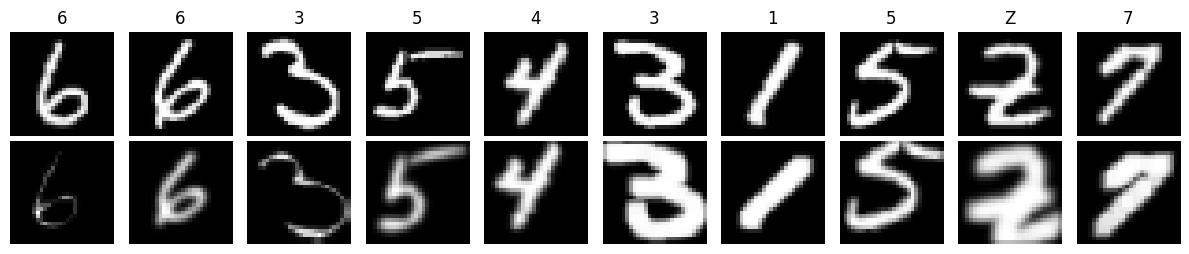

Epoch 1/5 | train loss 0.8235 | val acc 88.09%
Epoch 2/5 | train loss 0.4952 | val acc 89.73%
Epoch 3/5 | train loss 0.4221 | val acc 90.32%
Epoch 4/5 | train loss 0.3892 | val acc 90.63%
Epoch 5/5 | train loss 0.3652 | val acc 90.78%
Best validation accuracy (augmented training): 90.78% (saved to /content/drive/MyDrive/Group4_project/char_cnn_aug_best.pt)


In [24]:
import math

def augment(x):
    """(B,1,28,28) in [-1,1] -> random tilt/shift/scale/shear, thicker or thinner strokes, blur."""
    B, dev = x.size(0), x.device
    x = (x + 1) / 2                                   # to [0,1] so empty padding stays black background
    ang = torch.empty(B, device=dev).uniform_(-12, 12) * math.pi / 180
    scale = torch.empty(B, device=dev).uniform_(0.85, 1.15)
    shear = torch.empty(B, device=dev).uniform_(-0.2, 0.2)
    tx = torch.empty(B, device=dev).uniform_(-0.12, 0.12)
    ty = torch.empty(B, device=dev).uniform_(-0.12, 0.12)
    cos, sin = torch.cos(ang) / scale, torch.sin(ang) / scale
    theta = torch.stack([torch.stack([cos, -sin + shear, tx], 1),
                         torch.stack([sin, cos, ty], 1)], 1)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, padding_mode='zeros', align_corners=False)

    r = torch.rand(B, device=dev).view(B, 1, 1, 1)
    thick = F.max_pool2d(x, 3, stride=1, padding=1)      # dilate: thicker strokes
    thin = -F.max_pool2d(-x, 3, stride=1, padding=1)     # erode: thinner strokes (like a fine pen)
    x = torch.where(r < 0.3, thick, x)
    x = torch.where(r > 0.85, thin, x)

    k = torch.tensor([1., 2., 1.], device=dev)
    k = (k[:, None] * k[None, :] / 16).view(1, 1, 3, 3)
    blurred = F.conv2d(x, k, padding=1)
    x = torch.where(torch.rand(B, device=dev).view(B, 1, 1, 1) < 0.3, blurred, x)
    return x * 2 - 1

# Quick visual check: top = original, bottom = augmented
xb, yb = next(iter(train_loader))
xa = augment(xb[:10].to(device)).cpu()
fig, axes = plt.subplots(2, 10, figsize=(12, 2.6))
for i in range(10):
    axes[0, i].imshow(xb[i, 0], cmap='gray'); axes[0, i].set_title(EMNIST_MAP[yb[i]]); axes[0, i].axis('off')
    axes[1, i].imshow(xa[i, 0], cmap='gray'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

# Same model, loss, optimizer settings and epochs as the baseline -- only the training images differ
model_aug = CharCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)
AUG_PATH = f'{PROJECT}/char_cnn_aug_best.pt'
best_val_aug = 0.0

for epoch in range(EPOCHS):
    model_aug.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = augment(x.to(device)), y.to(device)
        optimizer_aug.zero_grad()
        loss = criterion(model_aug(x), y)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item() * y.size(0)
    val_acc = evaluate(model_aug, val_loader)          # validation on normal (un-augmented) images
    print(f'Epoch {epoch + 1}/{EPOCHS} | train loss {running_loss / len(train_ds):.4f} | val acc {val_acc:.2%}')
    if val_acc > best_val_aug:
        best_val_aug = val_acc
        torch.save(model_aug.state_dict(), AUG_PATH)

print(f'Best validation accuracy (augmented training): {best_val_aug:.2%} (saved to {AUG_PATH})')

In [25]:
def read_cells_with(m, cells):
    """Like read_cells, but for any model m. Returns {field: text read}, empty box = ' '."""
    m.eval()
    out = {}
    for field, crops in cells.items():
        chars_ = []
        for i, crop in enumerate(crops):
            if crop is None:
                chars_.append(' ')
                continue
            x = to_model_input(crop[None]).to(device)
            with torch.no_grad():
                pred, _ = predict(m, x, allowed_classes(field, i))
            chars_.append(EMNIST_MAP[pred.item()])
        out[field] = ''.join(chars_)
    return out

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model_aug.load_state_dict(torch.load(AUG_PATH, map_location=device))
models = {'baseline': model, 'augmented': model_aug}

rows = []
for path in sorted(glob.glob(f'{PROJECT}/synthetic_logs/*.png')):
    name = os.path.basename(path)[:-4]
    truth_i = json.load(open(path[:-4] + '.json'))
    cells_i, _, _ = extract_cells(cv2.imread(path))      # cut boxes once, read with both models
    gt_i = truth_fields(truth_i)
    for mname, m in models.items():
        reads_i = read_cells_with(m, cells_i)
        for field, true_text in gt_i.items():
            read_text = reads_i[field]
            pairs = list(zip(true_text, read_text))
            rows.append({'model': mname, 'condition': truth_i['condition'], 'log': name, 'field': field,
                         'field_ok': read_text == true_text,
                         'digits': sum(t.isdigit() for t, _ in pairs),
                         'digits_ok': sum(t == r for t, r in pairs if t.isdigit()),
                         'letters': sum(not t.isdigit() for t, _ in pairs),
                         'letters_ok': sum(t == r for t, r in pairs if not t.isdigit())})

cmp = pd.DataFrame(rows)

def summarize(g):
    odo = g[g['field'].str.contains('odo')]
    return pd.Series({'digit acc': g.digits_ok.sum() / g.digits.sum(),
                      'letter acc': g.letters_ok.sum() / g.letters.sum(),
                      'field acc': g.field_ok.mean(),
                      'odo >=3 of 6': (odo.digits_ok >= 3).mean(),
                      'odo 6 of 6': (odo.digits_ok == 6).mean()})

table = pd.DataFrame({(c, mn): summarize(cmp[(cmp.condition == c) & (cmp.model == mn)])
                      for c in order for mn in models}).T
print('Baseline vs augmented training -- same 60 synthetic logs, same extraction\n')
print(table.to_string(float_format='{:.1%}'.format))

cmp.to_csv(f'{PROJECT}/scorecard_baseline_vs_augmented.csv', index=False)

Baseline vs augmented training -- same 60 synthetic logs, same extraction

                 digit acc  letter acc  field acc  odo >=3 of 6  odo 6 of 6
clean baseline       98.2%       93.7%      89.3%        100.0%       88.1%
      augmented      98.8%       97.4%      93.6%        100.0%       91.1%
phone baseline       94.9%       85.8%      74.0%        100.0%       68.0%
      augmented      96.6%       92.7%      83.3%        100.0%       78.5%
rough baseline       87.9%       74.7%      52.7%        100.0%       45.0%
      augmented      92.6%       84.2%      69.0%        100.0%       64.2%


In [26]:
# Use the augmented model from here on (read_cells uses `model`)
model.load_state_dict(torch.load(AUG_PATH, map_location=device))
model.eval()

CONF_MIN = 0.50          # any character below this confidence -> human review
MAX_TRIP_MILES = 300     # longer trips are flagged as implausible

def validate(reads):
    """Check one log against the form's rules. Returns ('AUTO-POST' or 'REVIEW', [reasons])."""
    issues = []
    txt = lambda f: reads[f][0]

    try:
        we = dt.datetime.strptime(txt('week_ending'), '%m%d%y').date()
    except ValueError:
        we = None
        issues.append(f"week ending '{txt('week_ending')}' is not a valid date")

    rows = [r for r in range(9) if txt(f'r{r}_odo_start').strip() or txt(f'r{r}_miles').strip()]
    miles_sum, prev_end = 0, None
    for r in rows:
        tag = f'row {r + 1}'
        f = {k: txt(f'r{r}_{k}') for k in ['date', 'client', 'odo_start', 'odo_end', 'miles']}
        empty = [k for k, v in f.items() if ' ' in v]
        if empty:
            issues.append(f'{tag}: empty box in {", ".join(empty)}')
        try:
            s, e, m = int(f['odo_start']), int(f['odo_end']), int(f['miles'])
        except ValueError:
            continue
        miles_sum += m
        if e <= s:
            issues.append(f'{tag}: odometer end {e} is not after start {s}')
        elif e - s != m:
            issues.append(f'{tag}: miles written {m} but end - start = {e - s}')
        elif m > MAX_TRIP_MILES:
            issues.append(f'{tag}: {m} miles is implausibly long for one trip')
        if prev_end is not None and s < prev_end:
            issues.append(f'{tag}: odometer start {s} is before the previous row end {prev_end}')
        prev_end = e
        if we:
            try:
                d = dt.date(we.year, int(f['date'][:2]), int(f['date'][2:]))
                if d > we:                                   # week crossing New Year
                    d = d.replace(year=we.year - 1)
                if not (we - dt.timedelta(days=6) <= d <= we):
                    issues.append(f'{tag}: date {d:%m/%d} is outside the week ending {we:%m/%d/%y}')
            except ValueError:
                issues.append(f"{tag}: date '{f['date']}' is not a valid date")

    try:
        total = int(txt('total_miles'))
        if total != miles_sum:
            issues.append(f'total miles {total} does not match the sum of rows {miles_sum}')
    except ValueError:
        issues.append(f"total miles '{txt('total_miles')}' is unreadable")

    for field, (text, confs) in reads.items():
        low = [c for c in confs if c is not None and c < CONF_MIN]
        if low:
            issues.append(f'{field}: low confidence ({min(low):.2f})')

    return ('AUTO-POST' if not issues else 'REVIEW'), issues

# Run on all 60 logs and measure how safe the decisions are
log_rows = []
for path in sorted(glob.glob(f'{PROJECT}/synthetic_logs/*.png')):
    truth_i = json.load(open(path[:-4] + '.json'))
    cells_i, _, _ = extract_cells(cv2.imread(path))
    reads_i = read_cells(cells_i)
    decision, issues = validate(reads_i)
    wrong = [f for f, t in truth_fields(truth_i).items() if reads_i[f][0] != t]
    log_rows.append({'log': os.path.basename(path)[:-4], 'condition': truth_i['condition'],
                     'decision': decision, 'n_issues': len(issues),
                     'any_wrong': bool(wrong),
                     'money_wrong': any('odo' in f or 'miles' in f for f in wrong)})
logs = pd.DataFrame(log_rows)

safety = pd.DataFrame({c: {
    'logs': len(g),
    'auto-posted': (g.decision == 'AUTO-POST').sum(),
    'sent to review': (g.decision == 'REVIEW').sum(),
    'auto-posted WITH an error': ((g.decision == 'AUTO-POST') & g.any_wrong).sum(),
    'auto-posted WITH a mileage error': ((g.decision == 'AUTO-POST') & g.money_wrong).sum(),
    'reviewed but actually all correct': ((g.decision == 'REVIEW') & ~g.any_wrong).sum(),
} for c, g in logs.groupby('condition')}).T.reindex(order)

print('Auto-post vs review decisions -- augmented model, 20 synthetic logs per condition\n')
print(safety.to_string())

d, iss = validate(read_cells(extract_cells(cv2.imread(f'{PROJECT}/synthetic_logs/rough_00.png'))[0]))
print(f'\nExample, rough_00 -> {d}')
for i in iss:
    print('  -', i)
logs.to_csv(f'{PROJECT}/decisions_augmented.csv', index=False)

Auto-post vs review decisions -- augmented model, 20 synthetic logs per condition

       logs  auto-posted  sent to review  auto-posted WITH an error  auto-posted WITH a mileage error  reviewed but actually all correct
clean    20            2              18                          0                                 0                                  1
phone    20            0              20                          0                                 0                                  0
rough    20            0              20                          0                                 0                                  0

Example, rough_00 -> REVIEW
  - row 2: odometer end 717578 is not after start 719513
  - row 3: odometer end 711598 is not after start 719387
  - row 3: date '0002' is not a valid date
  - row 4: odometer end 710678 is not after start 719600
  - r2_date: low confidence (0.42)


In [27]:
from google.colab import files

# Drag your photo into Colab's Files panel (folder icon, left sidebar) and put its name here
PHOTO_PATH = '/content/test_photo.jpg'

if not os.path.exists(PHOTO_PATH):
    print('No photo at PHOTO_PATH -- choose one with the button below')
    up = files.upload()
    if not up:
        raise FileNotFoundError('No photo chosen')
    PHOTO_PATH = '/content/' + list(up)[0]

photo = cv2.imread(PHOTO_PATH)
if photo is None:
    raise ValueError(f'Could not open {PHOTO_PATH} -- if it is an iPhone HEIC photo, convert it to JPG first')

# 1. Find and straighten the form, cut out the boxes
try:
    cells_p, warped_p, n_inl = extract_cells(photo)
except ValueError as e:
    print('Could not find Form ML-7 in this photo:', e)
    print('Retake it with the whole form visible, flat, in good light.')
    raise

# 2. Read every box with the augmented model, 3. check the rules
reads_p = read_cells(cells_p)
decision_p, issues_p = validate(reads_p)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(photo[..., ::-1]); axes[0].set_title('Photo')
axes[1].imshow(warped_p[..., ::-1]); axes[1].set_title(f'Straightened ({n_inl} feature matches)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# What the model read
print(f"Employee ID: {reads_p['emp_id'][0]}    Week ending: {reads_p['week_ending'][0]}\n")
print(f"{'row':<5}{'date':<7}{'client':<8}{'odo start':<11}{'odo end':<11}{'miles':<6}")
filled = [r for r in range(9)
          if any(c is not None for k in ['date', 'client', 'odo_start', 'odo_end', 'miles']
                 for c in cells_p[f'r{r}_{k}'])]
for r in filled:
    g = lambda k: reads_p[f'r{r}_{k}'][0]
    print(f"{r + 1:<5}{g('date'):<7}{g('client'):<8}{g('odo_start'):<11}{g('odo_end'):<11}{g('miles'):<6}")
print(f"\nTotal miles: {reads_p['total_miles'][0]}")

# The crops the model actually saw, with what it read under each one
for r in filled:
    crops, labels = [], []
    for k in ['date', 'client', 'odo_start', 'odo_end', 'miles']:
        text, _ = reads_p[f'r{r}_{k}']
        for c, ch in zip(cells_p[f'r{r}_{k}'], text):
            crops.append(c if c is not None else np.full((28, 28), 80, np.uint8))
            labels.append(ch)
    fig, axes = plt.subplots(1, len(crops), figsize=(len(crops) * 0.6, 1))
    for ax, c, ch in zip(axes, crops, labels):
        ax.imshow(c, cmap='gray'); ax.set_title(ch, fontsize=9); ax.axis('off')
    fig.suptitle(f'Row {r + 1}', x=0.02, ha='left', fontsize=9)
    plt.show()

print(f'\nDecision: {decision_p}')
for i in issues_p:
    print('  -', i)

No photo at PHOTO_PATH -- choose one with the button below


FileNotFoundError: No photo chosen